In [2]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

In [6]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler took a wicket with a yorker",
    "India won the cricket match by 5 runs",
    "The captain set an aggressive field placement",

    # Cooking (3)
    "I cooked a delicious pasta for dinner",
    "The recipe requires fresh vegetables and spices",
    "Baking a cake needs precise measurements",

    # Cybersecurity (3)
    "Cybersecurity protects systems from digital attacks",
    "Strong passwords help prevent unauthorized access",
    "Encryption secures sensitive data from hackers"
]

In [7]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 9.99999881e-01  5.15466213e-01  5.61958551e-01  2.15013355e-01
  -1.20963305e-02  5.54596148e-02  1.48730159e-01  1.78175122e-02
  -5.19663244e-02  6.82286033e-03]
 [ 5.15466213e-01  1.00000024e+00  5.07794857e-01  1.93166673e-01
   1.43289268e-01  8.99585038e-02  1.03556104e-01 -2.25573089e-02
  -7.59545416e-02  2.32319185e-03]
 [ 5.61958551e-01  5.07794857e-01  1.00000000e+00  5.03117070e-02
   7.40937889e-02  6.32780045e-02  4.54510637e-02  1.05481252e-01
  -1.56922322e-02  8.27620476e-02]
 [ 2.15013355e-01  1.93166673e-01  5.03117070e-02  1.00000012e+00
  -3.05134337e-02  8.04560259e-04 -4.17706557e-02 -1.15469387e-02
   5.99745400e-02 -1.82062946e-02]
 [-1.20963305e-02  1.43289268e-01  7.40937889e-02 -3.05134337e-02
   1.00000012e+00  2.52976865e-01  7.60643482e-02 -2.07181647e-02
  -1.37556288e-02  4.22346033e-02]
 [ 5.54596148e-02  8.99585038e-02  6.32780045e-02  8.04560259e-04
   2.52976865e-01  1.00000000e+00  1.27530620e-01 -5.17980233e-02
   1.13840876e-02  1.87527947e-02

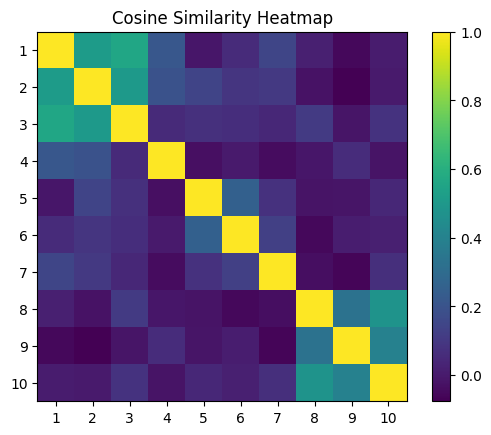

In [11]:
plt.figure()
plt.imshow(similarity_matrix)
plt.colorbar()

plt.xticks(range(len(sentences)), range(1,11))
plt.yticks(range(len(sentences)), range(1,11))

plt.title("Cosine Similarity Heatmap")
plt.show()

In [10]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_2_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_2_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler took a wicket with a yorker
Similarity Score: 0.7487

Sentence: India won the cricket match by 5 runs
Similarity Score: 0.5856



Mounted at /content/drive
